In [1]:
import geopandas as gpd
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


'''# Замените 'data.geojson' на путь к вашему скачанному файлу
geojson_path = 'moskva.geojson'
csv_path1 = 'moskva.csv'

# 1. Загрузка данных из GeoJSON в GeoDataFrame
gdf = gpd.read_file(geojson_path)

# 2. Преобразование GeoDataFrame в обычный DataFrame Pandas и экспорт в CSV
# При этом координаты (geometry) могут быть сохранены в отдельном столбце в формате WKT (Well-Known Text)
# или же столбцы с широтой и долготой можно извлечь отдельно.

# Извлечение широты и долготы в отдельные столбцы
gdf['latitude'] = gdf.geometry.y
gdf['longitude'] = gdf.geometry.x

# Удаляем исходный столбец geometry
gdf = gdf.drop(columns=['geometry'])

# Сохраняем результат в CSV файл
gdf.to_csv(csv_path1, index=False, encoding='utf-8')

print(f"Данные успешно сохранены в файл {csv_path1}")'''


'# Замените \'data.geojson\' на путь к вашему скачанному файлу\ngeojson_path = \'moskva.geojson\'\ncsv_path1 = \'moskva.csv\'\n\n# 1. Загрузка данных из GeoJSON в GeoDataFrame\ngdf = gpd.read_file(geojson_path)\n\n# 2. Преобразование GeoDataFrame в обычный DataFrame Pandas и экспорт в CSV\n# При этом координаты (geometry) могут быть сохранены в отдельном столбце в формате WKT (Well-Known Text)\n# или же столбцы с широтой и долготой можно извлечь отдельно.\n\n# Извлечение широты и долготы в отдельные столбцы\ngdf[\'latitude\'] = gdf.geometry.y\ngdf[\'longitude\'] = gdf.geometry.x\n\n# Удаляем исходный столбец geometry\ngdf = gdf.drop(columns=[\'geometry\'])\n\n# Сохраняем результат в CSV файл\ngdf.to_csv(csv_path1, index=False, encoding=\'utf-8\')\n\nprint(f"Данные успешно сохранены в файл {csv_path1}")'

In [41]:
#общий датасет для москвы и мо
df_m = pd.read_csv('moskva.csv')
df_mo = pd.read_csv('moskovskaia-oblast.csv')
df = pd.concat([df_m, df_mo], axis=0, ignore_index=True)

In [7]:
#дек 2015 - июнь 2025
df = df[((df['year'] < 2025) | ((df['year'] == 2025) & (df['month'].isin(['Янв', 'Февр', 'Март', 'Апр', 'Май', 'Июнь']))))]

In [9]:
#разделение по времени суток
df['hour'] = df['datetime'].dt.hour

bins = [0, 6, 12, 18, 24]
labels = ['Ночь', 'Утро', 'День', 'Вечер']

df['time_of_day'] = pd.cut(df['hour'], bins=bins, labels=labels, right=False, include_lowest=True)
df = df.drop(columns=['hour'])


/tmp/ipykernel_1192/3246485830.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df['datetime'].dt.hour
/tmp/ipykernel_1192/3246485830.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time_of_day'] = pd.cut(df['hour'], bins=bins, labels=labels, right=False, include_lowest=True)


In [6]:
#создание столбцов года и месяца отдельно
df['datetime'] = pd.to_datetime(df['datetime'])

df['year'] = df['datetime'].dt.year

df['month'] = df['datetime'].dt.month
month_map = {1: 'Янв', 2: 'Февр', 3: 'Март', 4: 'Апр', 5: 'Май', 6: 'Июнь',
             7: 'Июль', 8: 'Авг', 9: 'Сент', 10: 'Окт', 11: 'Нояб', 12: 'Дек'}

df['month'] = df['month'].map(month_map)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120879 entries, 0 to 120878
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      120879 non-null  int64  
 1   tags                    120879 non-null  object 
 2   light                   120879 non-null  object 
 3   point                   120879 non-null  object 
 4   nearby                  120879 non-null  object 
 5   region                  120879 non-null  object 
 6   scheme                  120879 non-null  int64  
 7   address                 110373 non-null  object 
 8   weather                 120879 non-null  object 
 9   category                120879 non-null  object 
 10  datetime                120879 non-null  object 
 11  severity                120879 non-null  object 
 12  vehicles                120879 non-null  object 
 13  dead_count              120879 non-null  int64  
 14  gibdd_number        

In [3]:
#чтоб вся таблица выводилась
pd.reset_option('display.max_colwidth')
pd.set_option('display.max_columns', 24)

In [8]:
df.head()

,id,tags,light,point,nearby,region,scheme,address,weather,category,datetime,severity,...,dead_count,gibdd_number,participants,injured_count,parent_region,road_conditions,participants_count,participant_categories,latitude,longitude,year,month
0,6,['Дорожно-транспортные происшествия'],"В темное время суток, освещение включено","{'lat': 55.689444, 'long': 37.608056}",['Отсутствие в непосредственной близости объек...,Котловка,610,"г Москва, ул Черемушкинская Б., 1",['Пасмурно'],Наезд на препятствие,2015-01-01 00:23:00,С погибшими,...,1,157054063,[],1,Москва,"['Отсутствие, плохая различимость вертикальной...",2,['Все участники'],55.689444,37.608056,2015,Янв
1,22,['Дорожно-транспортные происшествия'],"В темное время суток, освещение включено","{'lat': 55.661667, 'long': 37.752778}",['Жилые дома индивидуальной застройки' 'Нерегу...,Марьино,740,"г Москва, ул Братиславская, 10",['Пасмурно'],Наезд на пешехода,2015-01-01 01:00:00,Тяжёлый,...,0,157125004,"[{'id': 3086339, 'role': 'Пешеход', 'gender': ...",1,Москва,['Не установлены'],2,['Все участники' 'Пешеходы'],55.661667,37.752778,2015,Янв
2,44,['Дорожно-транспортные происшествия'],"В темное время суток, освещение включено","{'lat': 55.649444, 'long': 37.405833}",['Выезд с прилегающей территории' 'Остановка о...,Солнцево,210,"г Москва, пр-кт Солнцевский, 14",['Пасмурно'],Столкновение,2015-01-01 01:39:00,Тяжёлый,...,0,157067635,[],1,Москва,['Недостатки зимнего содержания'],3,['Все участники'],55.649444,37.405833,2015,Янв
3,77,['Дорожно-транспортные происшествия'],"В темное время суток, освещение включено","{'lat': 55.851389, 'long': 37.569167}",['Отсутствие в непосредственной близости объек...,Бескудниковский,590,"г Москва, ш Дмитровское, 58-А",['Пасмурно'],Наезд на препятствие,2015-01-01 03:00:00,Тяжёлый,...,0,161850074,[],1,Москва,['Не установлены'],1,['Все участники'],55.851389,37.569167,2015,Янв
4,91,['Дорожно-транспортные происшествия'],"В темное время суток, освещение включено","{'lat': 55.730833, 'long': 37.338889}","['Объект (здание, сооружение) религиозного кул...",Рязанский,60,"г Москва, пр-кт Рязанский, 9",['Пасмурно'],Столкновение,2015-01-01 03:35:00,Легкий,...,0,159327097,[],1,Москва,['Неудовлетворительное состояние разделительно...,3,['Все участники'],55.730833,37.338889,2015,Янв


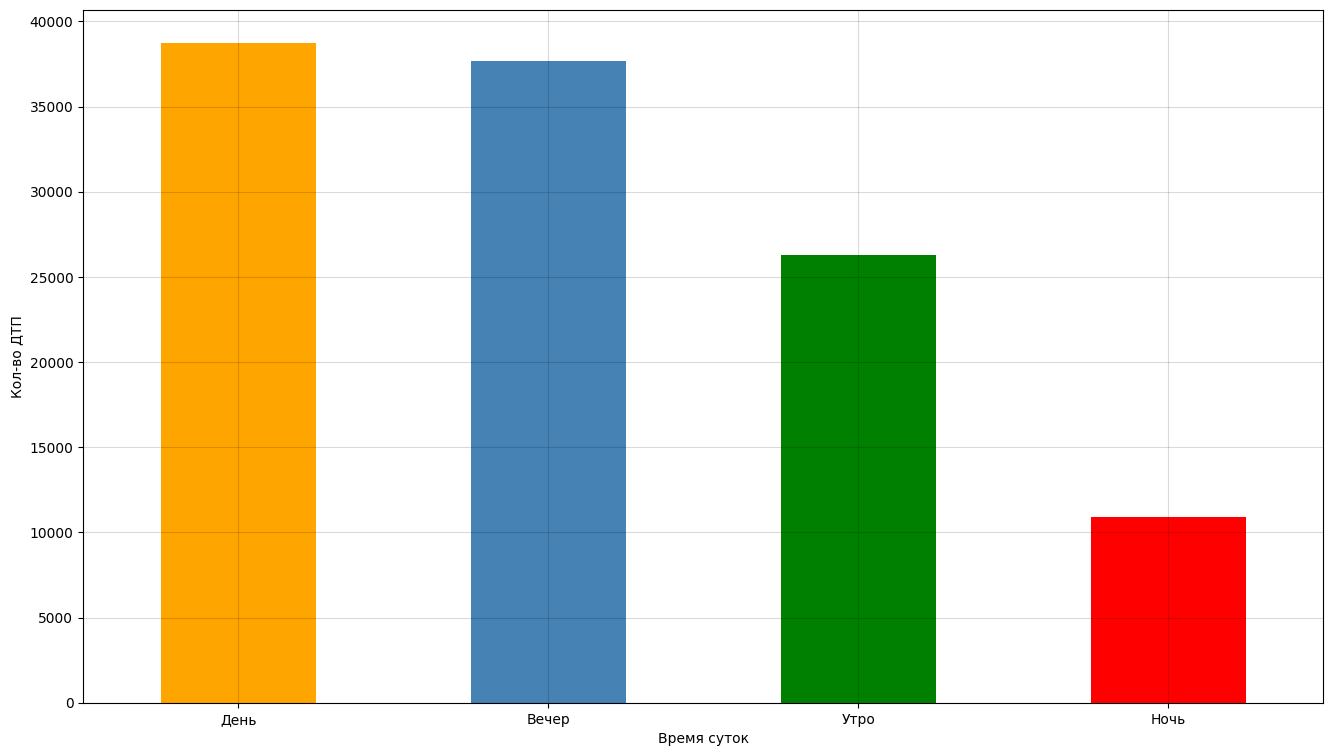

In [19]:
time_distribution = df['time_of_day'].value_counts()

plt.figure(figsize=(16, 9))

time_distribution.plot(
    kind='bar',
    color=['orange', 'steelblue', 'green', 'red']
)
plt.grid(color='black', alpha=0.15)
plt.xlabel('Время суток')
plt.ylabel('Кол-во ДТП')
plt.xticks(rotation=0)
#plt.savefig('время суток', dpi=300)

In [42]:
#для вывода строками
import ast

df['weather'] = df['weather'].apply(ast.literal_eval)
weather = df['weather'].explode()
df['weather'] = df['weather'].apply(lambda x: x[0] if isinstance(x, list) else x)

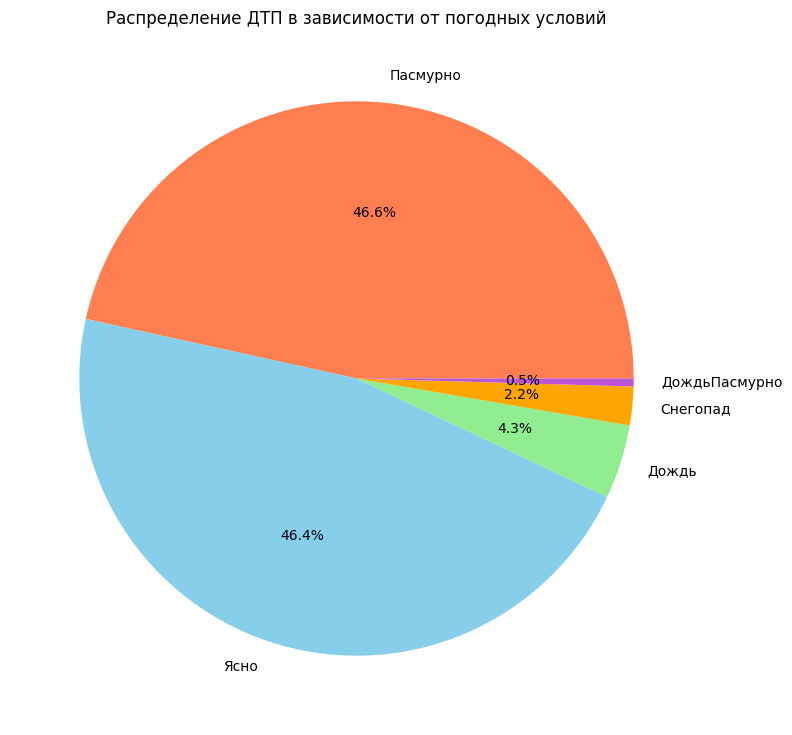

In [58]:
weather_distribution = df['weather'].value_counts()

plt.figure(figsize=(16, 9))

weather_top = df['weather'].value_counts().head(5)

weather_top.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['coral','skyblue','lightgreen','orange','mediumorchid']
)

plt.title("Распределение ДТП в зависимости от погодных условий")
plt.ylabel("")
plt.savefig('погодные условия', dpi=300)

In [ ]:
# список столбцов, используемых в анализе
columns = [
    "datetime",
    "severity",
    "light",
    "weather",
    "category",
    "dead_count",
    "injured_count"
]

# вывод примера данных
df[columns].head()

,datetime,severity,light,weather,category,dead_count,injured_count
0,2023-06-14 17:55:00,Легкий,Светлое время суток,['Ясно'],Столкновение,0,1
1,2015-04-14 18:00:00,Легкий,Светлое время суток,['Пасмурно'],Столкновение,0,1
2,2015-02-25 16:34:00,Тяжёлый,Светлое время суток,['Ясно'],Столкновение,0,1
3,2015-02-18 09:45:00,Легкий,Светлое время суток,['Ясно'],Наезд на пешехода,0,1
4,2015-02-17 18:40:00,Легкий,Светлое время суток,['Ясно'],Столкновение,0,1


/tmp/ipython-input-2732806834.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index='month', columns='year', values='dead_count', aggfunc='sum')


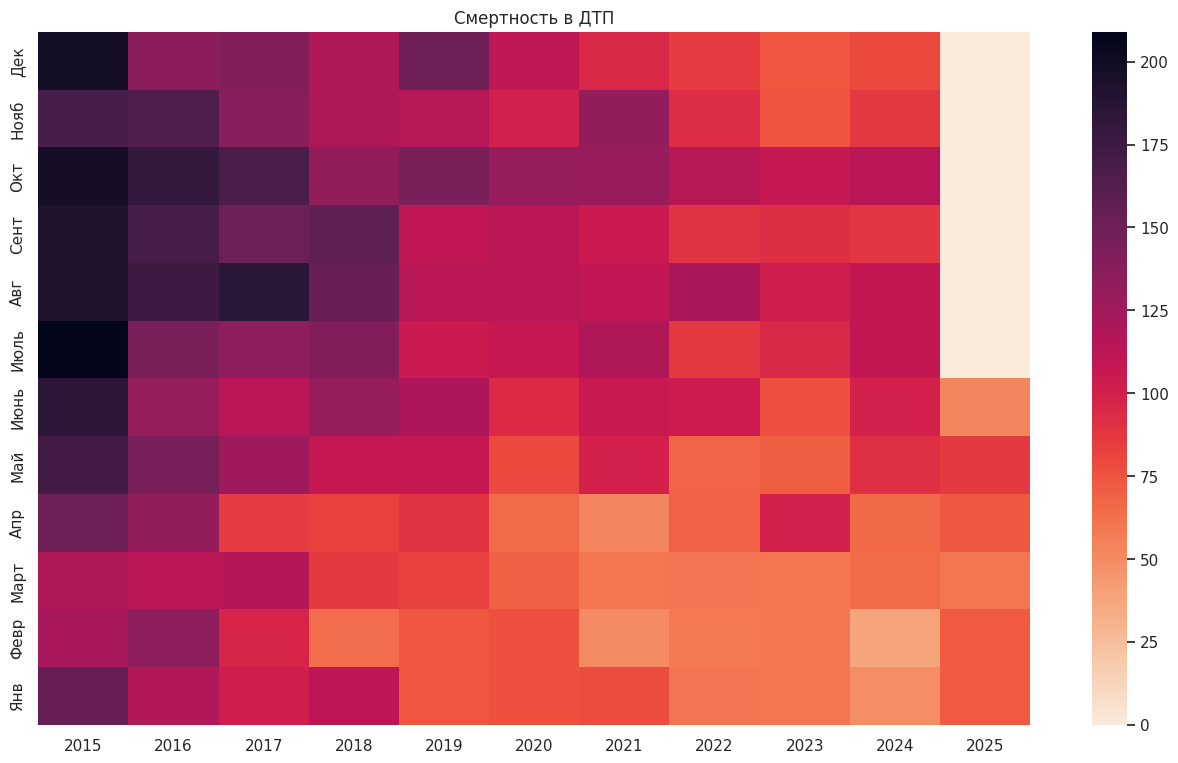

In [ ]:
sns.set(font_scale=1, style="white")

month_order = ['Дек', 'Нояб', 'Окт', 'Сент', 'Авг', 'Июль',
               'Июнь', 'Май', 'Апр', 'Март', 'Февр', 'Янв']

df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

data_df = (
    df
    .pivot_table(index='month', columns='year', values='dead_count', aggfunc='sum')
)

f, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(data_df, cmap='rocket_r', ax=ax)
ax.set(xlabel="", ylabel="")
ax.set(title='Смертность в ДТП')
#plt.savefig('смертность в дтп тепловая карта', dpi=300)

In [ ]:
df['year + month'] = df['year'].astype(str) + ' ' + df['month']

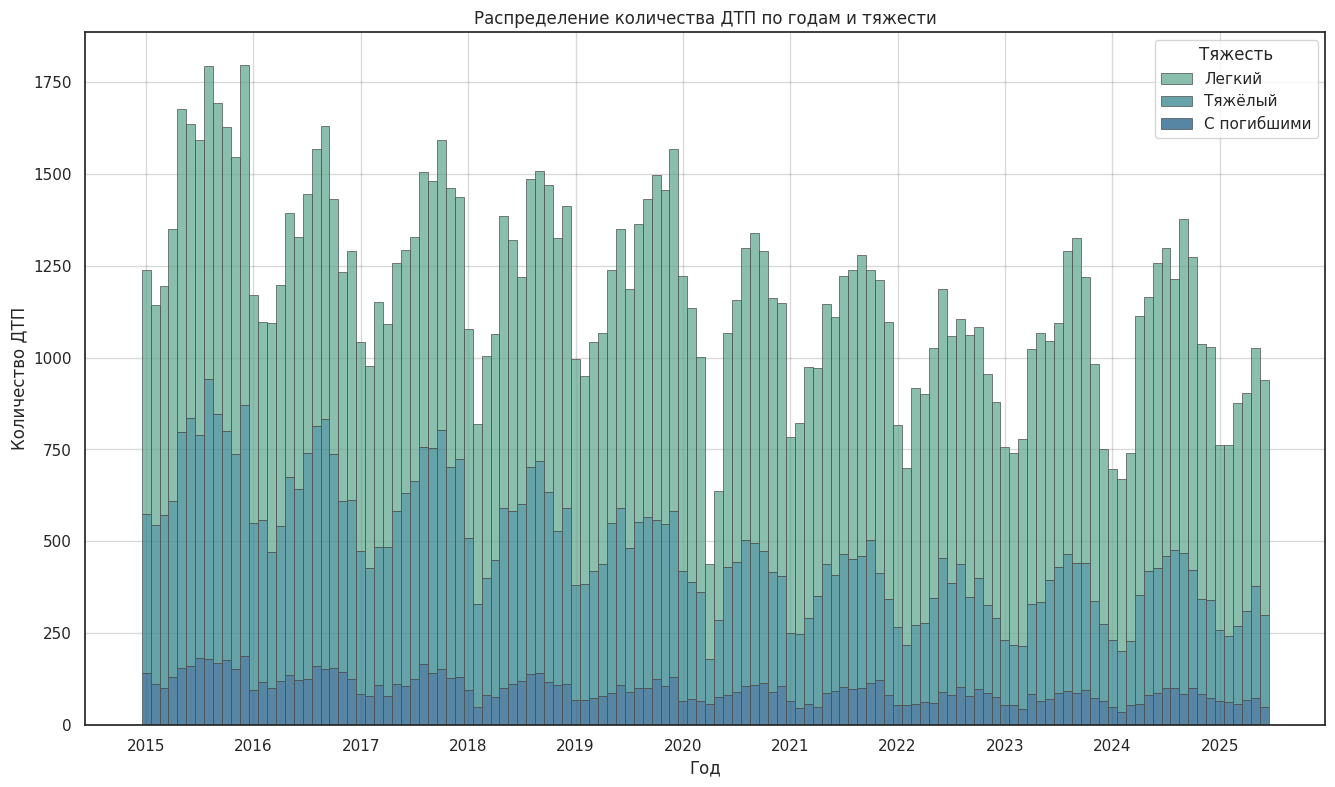

In [ ]:
from matplotlib.colors import Colormap
import matplotlib.ticker as mticker

sns.set(font_scale=1)

plt.figure(figsize=(16, 9))
sns.set_theme(style="white")

df['sort_key'] = df['datetime'].dt.to_period('M')

ordered_categories = df.sort_values('sort_key')['year + month'].unique()

df['year + month'] = pd.Categorical(df['year + month'], categories=ordered_categories, ordered=True)

ax = sns.histplot(
    df,
    x='year + month', hue='severity',
    multiple="stack",
    edgecolor=".3",
    linewidth=.5,
    log_scale=True,
    palette = "crest"
)

ordered_months = df['year + month'].cat.categories.tolist()
year_tick_positions = []
year_tick_labels = []

for i, month_label in enumerate(ordered_months):
    if 'Янв' in month_label:
        year_tick_positions.append(i)
        year_tick_labels.append(month_label.split(' ')[0])

ax.set_xticks(year_tick_positions)
ax.set_xticklabels(year_tick_labels)

ax.get_legend().set_title('Тяжесть')

plt.title('Распределение количества ДТП по годам и тяжести')
plt.xlabel('Год')
plt.ylabel('Количество ДТП')
plt.grid(color='black', alpha=0.15)

df.drop(columns=['sort_key'], inplace=True)
#plt.savefig('Распределение количества ДТП по годам и тяжести', dpi=300)

In [ ]:
df['road_conditions'] = df['road_conditions'].replace("['Отсутствие, плохая различимость горизонтальной разметки проезжей части'\n 'Сухое']", 'Сухое, отсутствие/плохая различимость горизонтальной разметки проезжей части')

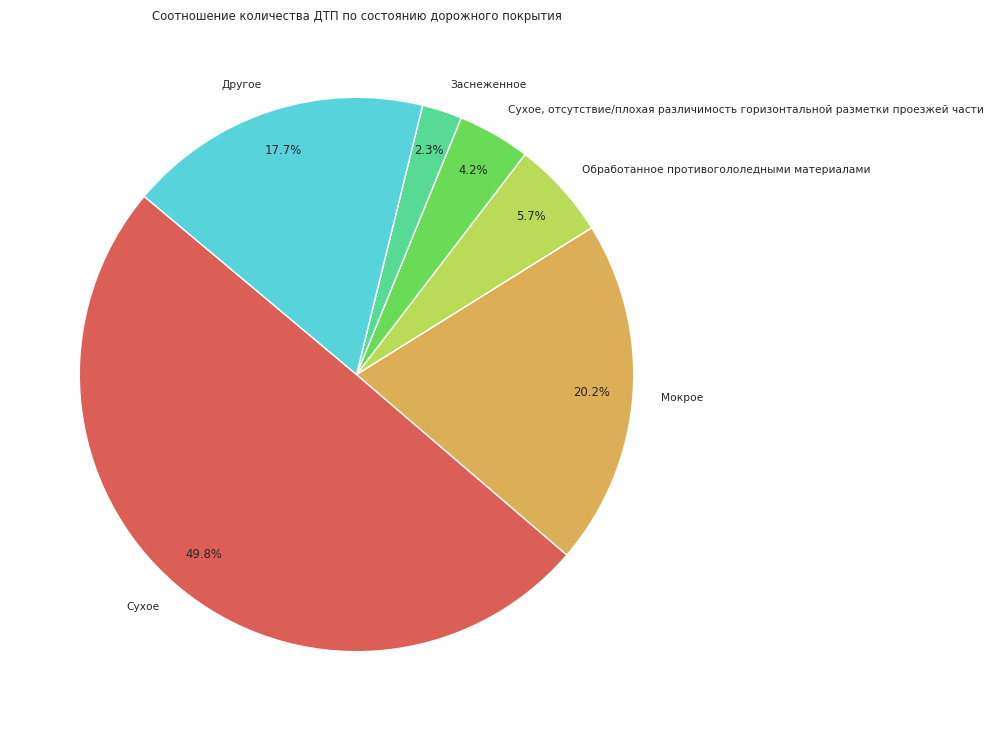

In [ ]:
import ast

def safe_literal_eval_to_list(s):
    if not isinstance(s, str):
        return [str(s)] if not isinstance(s, list) else s

    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return val
        else:
            return [str(val)]
    except (ValueError, SyntaxError):
        return [s.strip()]


df['road_conditions_list'] = df['road_conditions'].apply(safe_literal_eval_to_list)

all_conditions_exploded = df['road_conditions_list'].explode()

condition_counts = all_conditions_exploded.value_counts()

top_5_conditions = condition_counts.head(5).index.tolist()


plot_data = condition_counts.copy()

other_sum = plot_data[~plot_data.index.isin(top_5_conditions)].sum()
plot_data = plot_data.loc[top_5_conditions]
plot_data = pd.concat([plot_data, pd.Series({'Другое': other_sum})])

plot_data = plot_data[plot_data > 0]

colors = sns.color_palette("hls", 10)[:len(plot_data)]

sns.set(font_scale = 0.7)

plt.figure(figsize=(16, 9))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=140, pctdistance=0.85, colors=colors)

plt.title('Соотношение количества ДТП по состоянию дорожного покрытия')
#plt.savefig('Соотношение количества ДТП по состоянию дорожного покрытия', dpi=300)

In [ ]:
df_2015_2024 = df[df['year'].isin([2015, 2024])][['year', 'severity', 'injured_count']]
print(df_2015_2024.head(10))

    year severity  injured_count
1   2015   Легкий              1
2   2015  Тяжёлый              1
3   2015   Легкий              1
4   2015   Легкий              1
5   2015   Легкий              1
6   2015  Тяжёлый              1
7   2015   Легкий              1
8   2015   Легкий              1
33  2024   Легкий              1
40  2024   Легкий              1


In [ ]:
chart_df = (
    df_2015_2024
    .pivot_table(index='severity', columns='year', values='month', aggfunc='count')
)

In [ ]:
chart_df

year,2015,2024
severity,,
Легкий,9358,8498
С погибшими,1856,915
Тяжёлый,7065,3459


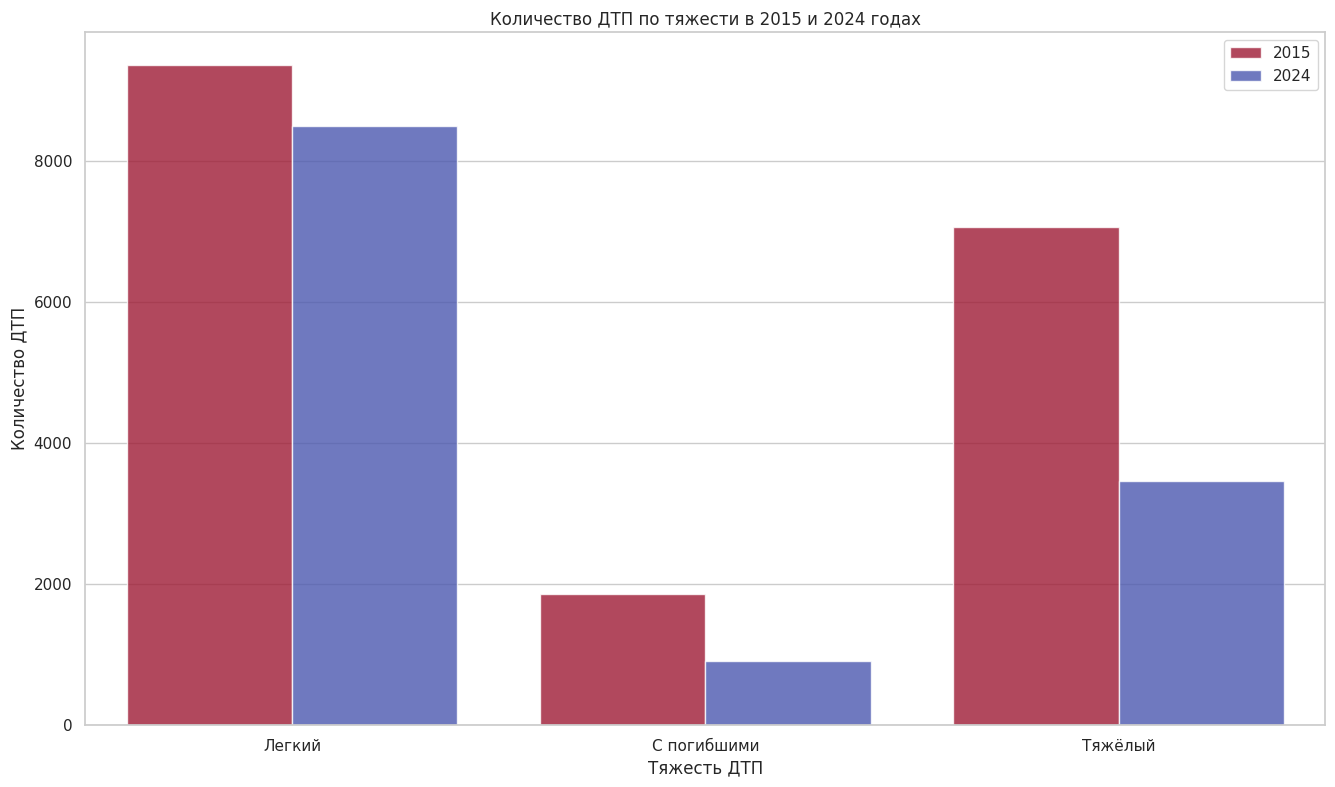

In [ ]:

sns.set_theme(style="whitegrid", font_scale=1)

plot_data_dtp = chart_df.reset_index().melt(id_vars='severity', var_name='year', value_name='count_dtp')

plt.figure(figsize=(16, 9))
sns.barplot(
    data=plot_data_dtp,
    x='severity',
    y='count_dtp',
    hue='year',
    palette='coolwarm_r', alpha=0.8
)

plt.title('Количество ДТП по тяжести в 2015 и 2024 годах')
plt.xlabel('Тяжесть ДТП')
plt.ylabel('Количество ДТП')
plt.legend(title='')

#sddsplt.savefig('Количество ДТП по тяжести в 2015 и 2024 годах', dpi=300)

In [ ]:
set(df['light'])

{'В темное время суток, освещение включено',
 'В темное время суток, освещение не включено',
 'В темное время суток, освещение отсутствует',
 'Не установлено',
 'Светлое время суток',
 'Сумерки'}

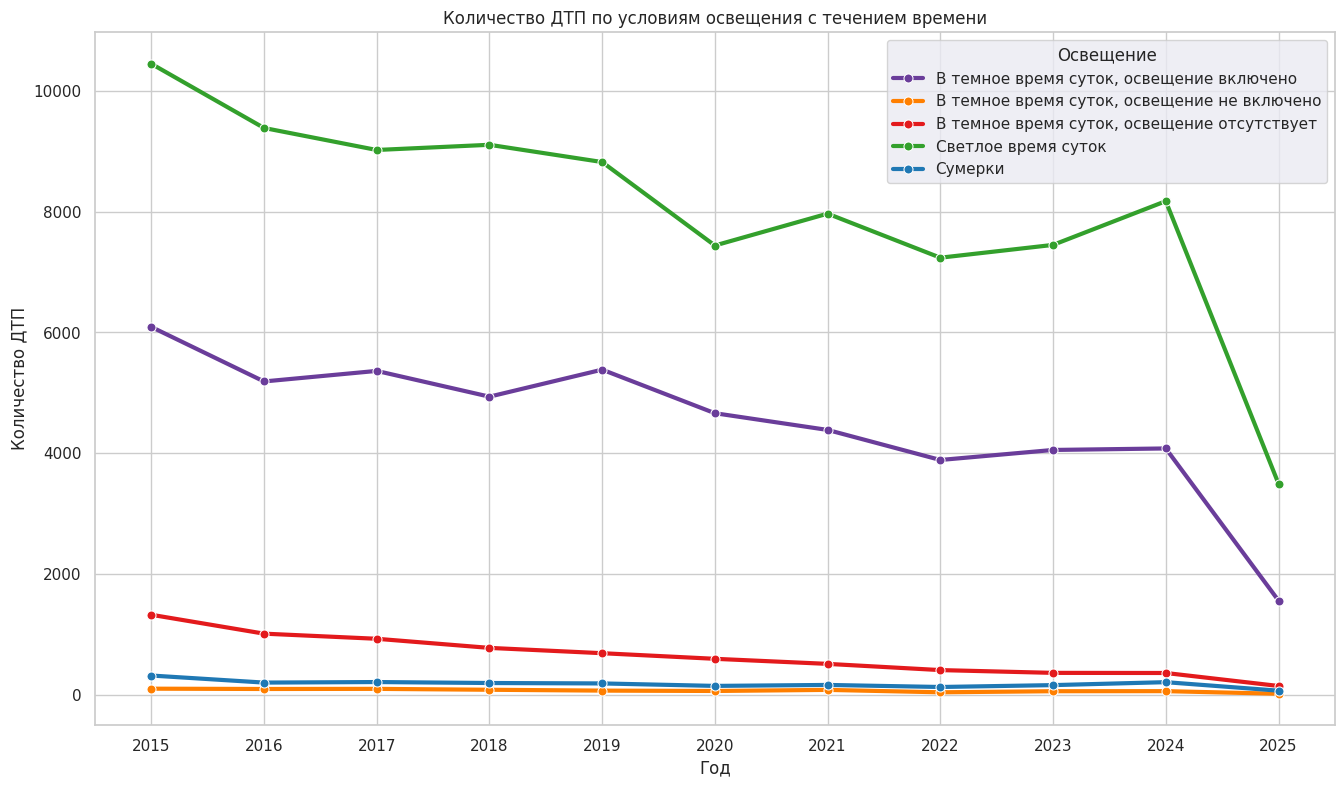

In [ ]:
df_filtered_light = df[df['light'] != 'Не установлено'].copy()


light_counts_over_time = df_filtered_light.groupby(['year', 'light']).size().reset_index(name='count_dtp')


plt.figure(figsize=(16, 9))

sns.set_theme(style="whitegrid")

plot = sns.lineplot(
    data=light_counts_over_time,
    x='year',
    y='count_dtp',
    hue='light',
    style='light',
    marker='o', dashes=False, markersize=6.5, linewidth=3,
    palette='Paired_r'
)

sns.set(font_scale=1)
plt.title('Количество ДТП по условиям освещения с течением времени')
plt.xlabel('Год')
plt.ylabel('Количество ДТП')
plt.xticks(list(range(2015, 2026)))
plt.legend(title='Освещение')

#plt.savefig('Количество ДТП по условиям освещения с течением времени', dpi=300)